# Housing Price Prediction

**Import Libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report
import warnings
warnings.filterwarnings('ignore')

**Loading Dataset**

In [5]:
df = pd.read_csv('/content/drive/MyDrive/1553768847-housing.csv')
display(df.head())
display(df.tail())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700
20639,-121.24,39.37,16,2785,616.0,1387,530,2.3886,INLAND,89400


**Basic Info**

In [6]:
print('Shape:', df.shape)
print()
df.info()
print()
df.describe()

Shape: (20640, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


**Cleaning Missing Value's**

In [7]:
print('Missing values before cleaning:')
print(df.isnull().sum())

df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

print()
print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values before cleaning:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

Missing values after cleaning:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64


**Visualization**

In [8]:
sns.set(style='whitegrid')

**1- Median House Value Distribution**

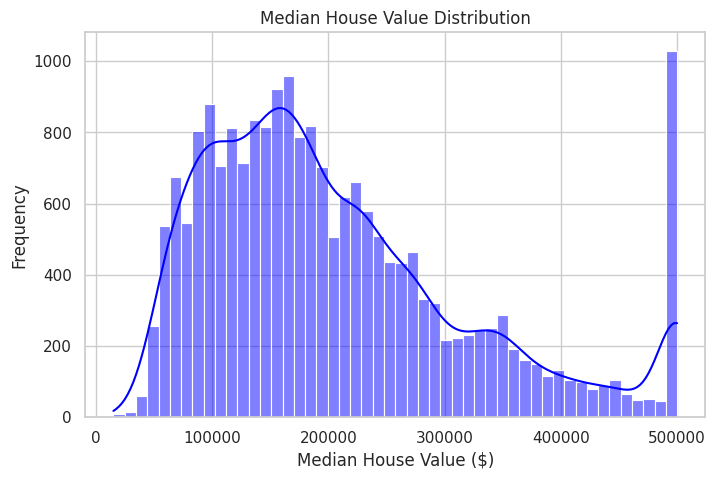

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df['median_house_value'], kde=True, color='blue', bins=50)
plt.title('Median House Value Distribution')
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency')
plt.show()

**2- Median Income vs House Value**

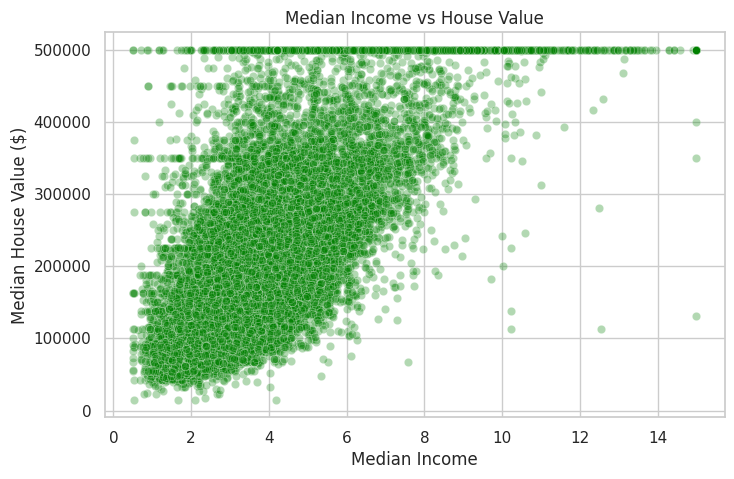

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.3, color='green')
plt.title('Median Income vs House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value ($)')
plt.show()

**3- House Value by Ocean Proximity**

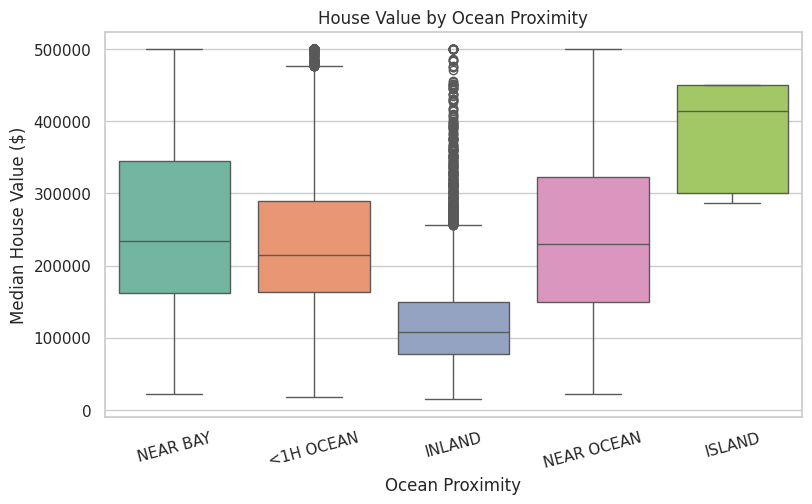

In [11]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df, palette='Set2')
plt.title('House Value by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value ($)')
plt.xticks(rotation=15)
plt.show()

**4- Correlation Heatmap**

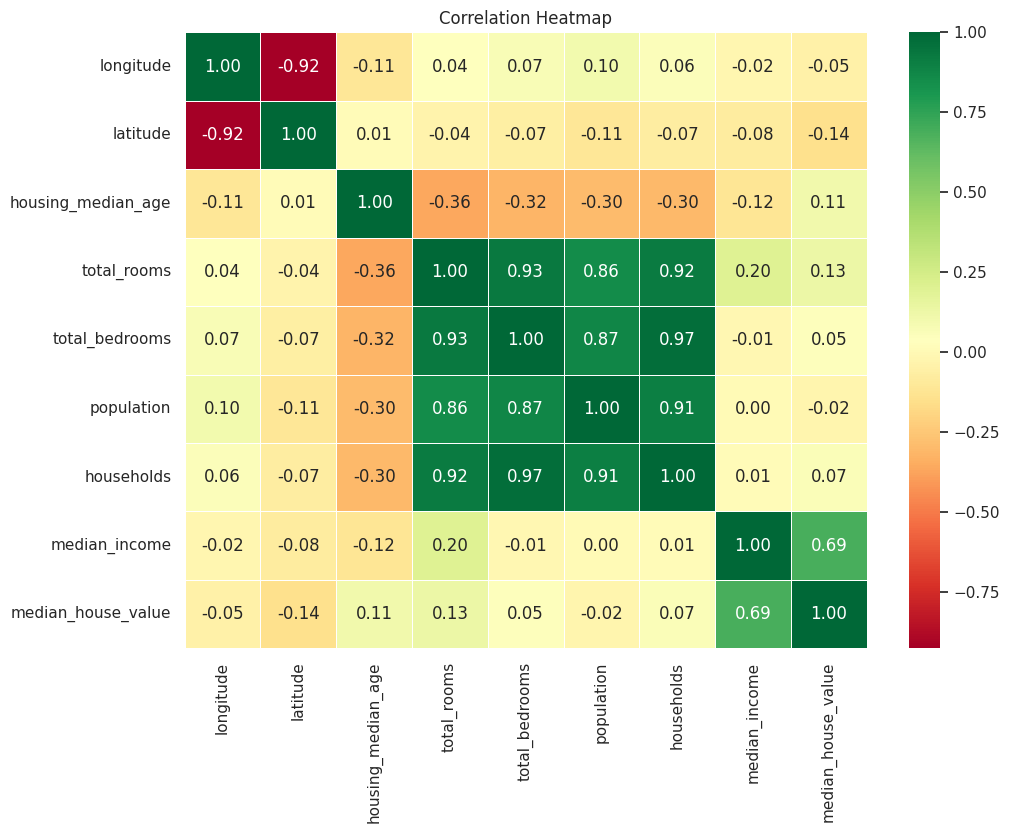

In [12]:
plt.figure(figsize=(11, 8))
df_num = df.drop('ocean_proximity', axis=1)
sns.heatmap(df_num.corr(), annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Feature Engineering**

In [13]:
df['rooms_per_household']      = df['total_rooms']    / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']     / df['households']

le = LabelEncoder()
df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

print('Feature Engineering complete. New shape:', df.shape)
display(df.head())

Feature Engineering complete. New shape: (20640, 13)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41,880,129.0,322,126,8.3252,3,452600,6.984127,0.146591,2.555556
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,3,358500,6.238137,0.155797,2.109842
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,3,352100,8.288136,0.129516,2.802260
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,3,341300,5.817352,0.184458,2.547945
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,3,342200,6.281853,0.172096,2.181467


**Splitting Features and Target**

In [14]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print('Features shape :', X.shape)
print('Target shape   :', y.shape)
print('Feature columns:', list(X.columns))

Features shape : (20640, 12)
Target shape   : (20640,)
Feature columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']


**Train-Test Split (80% Train, 20% Test)**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set size:', X_train.shape)
print('Test set size    :', X_test.shape)

Training set size: (16512, 12)
Test set size    : (4128, 12)


**Linear Regression**

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print('Linear Regression model trained successfully!')

Linear Regression model trained successfully!


**Model Evaluation**

In [17]:
mae  = mean_absolute_error(y_test, lr_preds)
mse  = mean_squared_error(y_test, lr_preds)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, lr_preds)

print('--- Linear Regression Results ---')
print(f'MAE  (Mean Absolute Error) : {mae:,.2f}')
print(f'MSE  (Mean Squared Error)  : {mse:,.2f}')
print(f'RMSE (Root Mean Sq. Error) : {rmse:,.2f}')
print(f'R2   (R-Squared Score)     : {r2:.4f}')

--- Linear Regression Results ---
MAE  (Mean Absolute Error) : 51,941.97
MSE  (Mean Squared Error)  : 5,515,599,258.32
RMSE (Root Mean Sq. Error) : 74,267.08
R2   (R-Squared Score)     : 0.5791


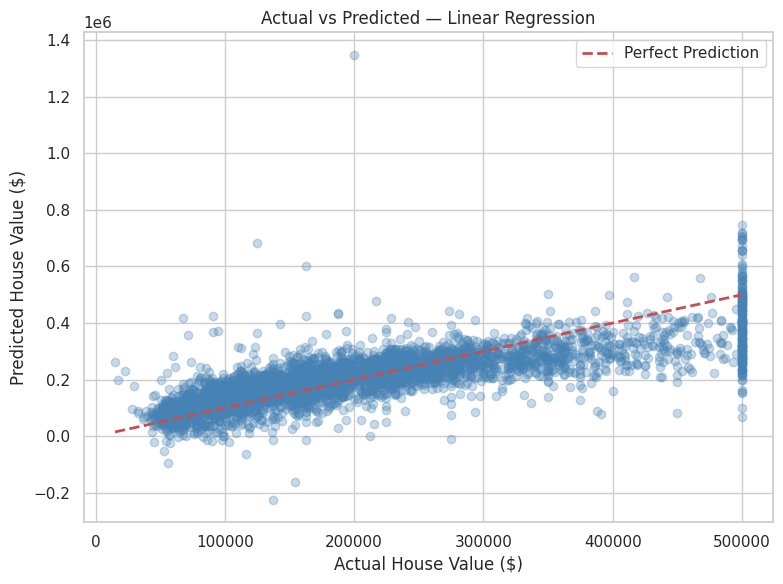

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_preds, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual House Value ($)')
plt.ylabel('Predicted House Value ($)')
plt.title('Actual vs Predicted — Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

**Classification Report**

In [19]:
# Regression values ko 3 price categories mein convert karna
# Low: <$120K  |  Medium: $120K-$280K  |  High: >$280K

def price_category(val):
    if val < 120000:
        return 'Low'
    elif val < 280000:
        return 'Medium'
    else:
        return 'High'

y_test_cat  = y_test.apply(price_category)
y_preds_cat = pd.Series(lr_preds).apply(price_category)

print('--- Classification Report (Price Categories) ---')
print('Low: <$120K  |  Medium: $120K-$280K  |  High: >$280K')
print()
print(classification_report(y_test_cat, y_preds_cat, target_names=['High', 'Low', 'Medium']))

--- Classification Report (Price Categories) ---
Low: <$120K  |  Medium: $120K-$280K  |  High: >$280K

              precision    recall  f1-score   support

        High       0.74      0.61      0.66       877
         Low       0.81      0.53      0.64      1041
      Medium       0.70      0.86      0.77      2210

    accuracy                           0.72      4128
   macro avg       0.75      0.67      0.69      4128
weighted avg       0.73      0.72      0.72      4128

